# Projekt: Wisconsin Breast Cancer Cells

 **1**  Illia Palagniuk   

**Verwendeter Datensatz:** Breast Cancer Wisconsin (Diagnostic) Datensatz

**Quelle:** UCI Machine Learning. (n.d.). Breast Cancer Wisconsin (Diagnostic) Data Set. Kaggle. Retrieved June 25, 2026, from https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

---

## Importe & Setup

In [1]:
# Standardbibliotheken aus Unterricht und Übung
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Weitere Imports
# Für Phase 3: Data Preparation
from sklearn.preprocessing import StandardScaler # um Merkmale mit unterschiedlichen Wertebereichen auf
# eine einheitliche Skala (Mittelwert 0 und Standardabweichung 1) zu normieren, damit Algorithmen nicht durch einzelne Variablen
#mit sehr großen Zahlen dominiert oder verzerrt werden.
from sklearn.model_selection import train_test_split # Für den sauberen Split
import plotly.express as px  # interaktive Feature-Übersicht
# Modelle für Phase 4: Modeling & Kreuzvalidierung
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
# Metriken für Phase 5: Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, accuracy_score


data_path = "data.csv"
df = pd.read_csv(data_path)

# Allgemeine Plot-Einstellungen
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

# 1. Business Understanding

## 1.1 Fachlicher Hintergrund und Problem
Die Diagnose von Brustkrebs ist zeitkritisch und aufwendig. Ein gängiges Verfahren ist die Feinnadelbiopsie (Fine Needle Aspiration, FNA): Dabei werden Zellen entnommen, mikroskopisch vergrößert und von Patholog:innen auf strukturelle Auffälligkeiten untersucht.

Diese Befundung ist aufwendig und hängt vom Menschen ab. Bei hohem Arbeitsaufkommen oder Ermüdung können Einschätzungen unterschiedlich ausfallen. Für die Klinik ist das ein Problem, weil eine gleichbleibende und möglichst objektive Diagnosequalität wichtig ist. Genau hier setzt unser Projekt an.

## 1.2 Stakeholder
Bevor wir ein Ziel festlegen, schauen wir, wer von so einem System betroffen wäre und welche Interessen dabei aufeinandertreffen:

| Stakeholder | Rolle | Primäres Interesse |
| :--- | :--- | :--- |
| **Patholog:innen / Ärzt:innen** | Direkte Nutzer:innen des Triage-Systems | Entlastung bei der ersten Sichtung; schnelle, nachvollziehbare Risikoeinschätzung |
| **Patient:innen** | Betroffene der Diagnose | Zuverlässige Früherkennung; möglichst keine Fehldiagnosen in beide Richtungen |
| **Klinikleitung** | Auftraggeber / Betreiber | Effizienterer Befundworkflow; Qualitätssicherung |
| **Regulierung / Ethikkomitees** | Aufsicht & Zulassung | Nachweisbare Sicherheit, Fairness und Transparenz (vgl. EU AI Act) |
| **Data Scientists / IT** | Entwicklung & Betrieb | Robustheit, Wartbarkeit und Reproduzierbarkeit des Modells |

Die Interessen gehen teilweise auseinander: Die Klinikleitung will vor allem Effizienz, Patholog:innen wollen nachvollziehbare Vorschläge, und die Regulierung achtet auf Sicherheit. Diese Punkte fließen direkt in unsere Erfolgskriterien ein.

## 1.3 Ziel des Projekts (Business Objective)
Unser Ziel ist ein Klassifikationsmodell, das Zellbefunde automatisch vorbewertet, also eine Art Vorsortierung bzw. Triage. Anhand der digitalisierten Zelleigenschaften soll es einschätzen, ob ein Befund eher gutartig (benign) oder bösartig (malignant) ist.

Das Modell soll die Ärzt:innen nicht ersetzen, sondern unterstützen: Es liefert einen ersten Hinweis und hilft, Befunde zu priorisieren. Die eigentliche Diagnose trifft weiterhin der Mensch ("Human-in-the-Loop"). Als Ergebnis wollen wir ein trainiertes, reproduzierbares Modell, das für neue Zellkerndaten schnell eine Vorhersage ausgibt.

## 1.4 Data-Mining-Ziel
Daraus ergibt sich eine klare Aufgabe: eine **binäre Klassifikation** auf Basis von den Zellkernmerkmalen, mit der Zielvariable `diagnosis` (M = bösartig, B = gutartig). Es handelt sich um **überwachtes Lernen**.

Zwei Dinge sind uns dabei besonders wichtig: (1) ein möglichst hoher **Recall** für die bösartige Klasse, damit wir möglichst wenige gefährliche Fälle übersehen, und (2) ein **stabiles Modell**, das auch auf neuen Daten zuverlässig funktioniert (geprüft über stratifizierte Kreuzvalidierung). Die reine Gesamtgenauigkeit (Accuracy) steht ausdrücklich nicht im Vordergrund.

## 1.5 Erfolgskriterien, Trade-off und Risiken

### Quantitative Kriterien
Unsere Erfolgskriterien leiten wir in erster Linie aus den Kosten der beiden Fehlerarten sowie aus Literaturwerten ab. Daraus ergibt sich der Recall als Leitkriterium, ergänzt um Precision, den F1-Score und einen Stabilitätswert:

| Metrik | Zielwert | Begründung |
| :--- | :--- | :--- |
| **Recall (Sensitivität) Klasse M** | ≥ **0,95** | Primärkriterium: Minimierung der False Negatives (übersehene maligne Befunde) |
| **Precision Klasse M** | ≥ **0,90** | Sekundärkriterium: Begrenzung unnötiger Fehlalarme (False Positives) |
| **F1-Score Klasse M** | ≥ **0,92** | Balanciert Recall und Precision |
| **Std. der CV (Recall)** | ≤ **0,03** | Stabilitätsnachweis: Das Modell generalisiert konsistent |

Dass ein sehr hoher Recall auf diesem Datensatz überhaupt erreichbar ist, bestätigt die Literatur (Hossin et al. 2023: Sensitivität 97,87 %). Unseren Zielwert setzen wir mit ≥ 0,95 bewusst etwas unterhalb dieser Spitzenwerte an, da sie teils mit komplexeren Verfahren erzielt wurden, während wir uns auf gut interpretierbare klassische Modelle konzentrieren.
Zusätzlich definieren wir eine simple Heuristik als Baseline, die uns in der späteren Evaluation als direkter Vergleichsmaßstab dienen wird, um den tatsächlichen Mehrwert des Modells zu belegen.

### Kosten der Fehlerarten – das Leitprinzip
Recall und Precision lassen sich nicht gleichzeitig beliebig steigern. Für uns ist entscheidend, dass die beiden Fehlerarten völlig unterschiedlich viel kosten:
* Ein **False Negative** – ein bösartiger Befund wird als gutartig eingestuft. Das ist der schlimmste Fall: ein übersehener Krebs mit direkter Gefahr für die Patientin.
* Ein **False Positive** – ein gutartiger Befund wird als bösartig markiert. Das kostet nur eine zusätzliche Kontrolle durch die Ärzt:innen: ärgerlich, aber nicht gefährlich.

Diese Asymmetrie ist der rote Faden unseres Projekts. Sie erklärt, warum wir durchgehend den Recall über die Accuracy und die Precision stellen: bei der Wahl der Metriken (Kap. 2), beim `class_weight='balanced'` (Kap. 3) und bei der Threshold-Anpassung (Kap. 5). Damit das System aber nicht bei jedem Fall Alarm schlägt, ziehen wir mit Precision ≥ 0,90 eine Untergrenze ein.

### Ethische Risiken
Zwei Punkte nehmen wir zusätzlich ernst:
* **Automation Bias:** Ärzt:innen könnten der Vorhersage zu unkritisch vertrauen. Das System muss klar machen, dass es nur eine Unterstützung ist.
* **Fairness:** Der Datensatz enthält keine demografischen Angaben. Ob das Modell in bestimmten Gruppen schlechter funktioniert, lässt sich deshalb nicht prüfen.

---

## Kurzfazit Business Understanding
* **Ziel:** Schnellere und objektivere Erstbewertung von Gewebeproben (gutartig / bösartig) als Unterstützung für Patholog:innen.
* **Ergebnis:** Ein trainiertes Python-Modell, das aus Zellkerndaten automatisch eine Vorhersage erzeugt.
* **Wichtigstes Erfolgskriterium:** Ein möglichst hoher Recall für die bösartige Klasse, um gefährliche Fehldiagnosen zu vermeiden.

---
# 2. Data Understanding

## 2.1 Datensatz

Wir verwenden den **Breast Cancer Wisconsin (Diagnostic) Datensatz**. Die Daten stammen ursprünglich vom University of Wisconsin Hospital und sind öffentlich über das UCI Machine Learning Repository verfügbar (siehe Referenzen).

Jede Zeile beschreibt einen Befund anhand geometrischer und texturaler Zellkernmerkmale. Der Datensatz umfasst 569 Befunde und in der Original-CSV 33 Spalten, darunter eine leere Importspalte (`Unnamed: 32`).

Wichtig für uns: Der Datensatz enthält bereits berechnete numerische Merkmale und keine Rohbilder. Der Schwerpunkt liegt deshalb nicht auf Bildverarbeitung, sondern auf der statistischen Analyse und Klassifikation dieser Merkmale.

In [2]:
# Datensatz laden
df = pd.read_csv('data.csv')

print(f"Anzahl Zeilen (Beobachtungen): {df.shape[0]}")
print(f"Anzahl Spalten: {df.shape[1]}")
print()
df.head()

Anzahl Zeilen (Beobachtungen): 569
Anzahl Spalten: 33



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Die eigentliche Zielvariable ist `diagnosis`. Sie ordnet jeden Befund als **"B" (benign, gutartig)** oder **"M" (malignant, bösartig)** ein. Die übrigen 30 Spalten sind durchgehend numerische Merkmale, die wir im nächsten Abschnitt beschreiben.

## 2.2 Features

Die 30 numerischen Merkmale lassen sich in zehn Basismerkmale und drei statistische Aggregationsformen gliedern. Für jeden Zellkern wurden folgende zehn morphologische Eigenschaften erfasst:

| Basismerkmal | Bedeutung |
|---|---|
| `radius` | Mittlerer Abstand vom Zentrum zu den Randpunkten |
| `texture` | Standardabweichung der Graustufenwerte (Oberflächenstruktur) |
| `perimeter` | Umfang des Zellkerns |
| `area` | Fläche des Zellkerns |
| `smoothness` | Lokale Variation der Radiuslängen (Glätte des Randes) |
| `compactness` | Kompaktheit, berechnet als perimeter² / area − 1 |
| `concavity` | Ausmaß konkaver Einbuchtungen am Rand |
| `concave points` | Anzahl konkaver Randpunkte |
| `symmetry` | Symmetrie der Zellkernform |
| `fractal dimension` | Fraktale Dimension („Rauheit“ des Randes) |

Da innerhalb eines Bildes mehrere Zellkerne vermessen wurden, liegt für jedes Basismerkmal nicht nur ein einzelner Wert vor, sondern drei aggregierte Kennzahlen über alle vermessenen Zellkerne eines Befundes:

- **`_mean`**: Mittelwert des Merkmals
- **`_se`**: Standardfehler (standard error) des Merkmals
- **`_worst`**: Mittelwert der drei größten (auffälligsten) gemessenen Werte

Daraus ergeben sich 10 × 3 = 30 Merkmalsspalten. Die `_worst`-Werte sind klinisch besonders relevant, da sie die extremsten Zellkerne eines Befundes abbilden, während `_mean` einen Gesamteindruck liefert.

Alle 30 Merkmale sind durchgehend numerisch (Datentyp `float64`) und liegen auf unterschiedlichen Skalen (z. B. `area_mean` im dreistelligen, `smoothness_mean` im Bereich um 0,1). Dies ist für die spätere Modellierungsphase relevant, da insbesondere distanzbasierte Verfahren eine Skalierung der Merkmale erfordern.

In [3]:
# Übersicht über Datentypen und Spaltennamen
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

## 2.3 Datenqualität

Bevor wir mit der explorativen Analyse starten, prüfen wir den Datensatz systematisch auf fehlende Werte, Duplikate, irrelevante Spalten und die Verteilung der Zielvariable.

**Fehlende Werte:** Die Spalte `Unnamed: 32` enthält ausschließlich fehlende Werte (`NaN`). Alle übrigen 30 Merkmale sowie `id` und `diagnosis` haben **keine fehlenden Werte**. Bei den eigentlichen Messwerten ist der Datensatz vollständig.

**Duplikate und Eindeutigkeit:** Es gibt keine doppelten Zeilen und keine doppelten `id`-Werte. Jeder Befund ist damit eindeutig einem Fall zuordenbar.

**Irrelevante Spalten:** Sowohl `id` (reine Kennung) als auch `Unnamed: 32` (leer) tragen keine Information für die Klassifikation und werden aus dem Arbeitsdatensatz entfernt.

**Plausibilität der Werte:** Die deskriptive Statistik zeigt keine offensichtlich unplausiblen Werte (z. B. negative Flächen oder Radien). Die Minima und Maxima liegen in einem medizinisch nachvollziehbaren Bereich, klare Mess- oder Eingabefehler sind nicht erkennbar.

**Verteilung der Zielvariable:** Von den 569 Befunden sind 357 (≈ 62,7 %) gutartig (`B`) und 212 (≈ 37,3 %) bösartig (`M`). Die Klassen sind also **moderat unausgeglichen**. Das ist für uns relevant: Bei so einer Verteilung könnte ein Modell schon durch reines Raten der Mehrheitsklasse eine hohe Accuracy erreichen, ohne die kritischen bösartigen Fälle zuverlässig zu erkennen. Das greift direkt das Leitprinzip aus 1.5 auf: Bei dieser Verteilung ist die Accuracy trügerisch, deshalb bewerten wir das Modell über den Recall für die bösartige Klasse.

In [4]:
# Fehlende Werte je Spalte
print("Fehlende Werte je Spalte (nur Spalten mit NA):")
print(df.isna().sum()[df.isna().sum() > 0])
print()

# Duplikate prüfen
print(f"Anzahl vollständig doppelter Zeilen: {df.duplicated().sum()}")
print(f"Anzahl doppelter 'id'-Werte: {df['id'].duplicated().sum()}")

Fehlende Werte je Spalte (nur Spalten mit NA):
Unnamed: 32    569
dtype: int64

Anzahl vollständig doppelter Zeilen: 0
Anzahl doppelter 'id'-Werte: 0


           Anzahl  Anteil (%)
diagnosis                    
B             357        62.7
M             212        37.3


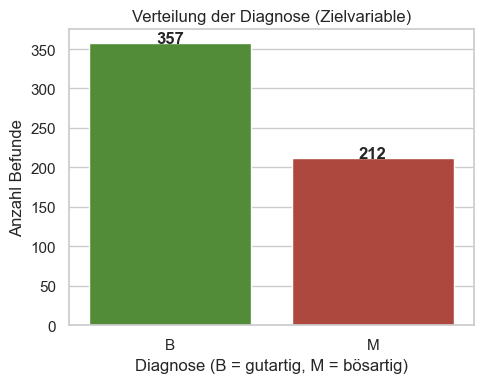

In [5]:
# Verteilung der Zielvariable
counts = df['diagnosis'].value_counts()
percentages = df['diagnosis'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Anzahl': counts, 'Anteil (%)': percentages.round(1)}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', order=['B', 'M'],
              palette={'B': '#4C9A2A', 'M': '#C0392B'}, legend=False, ax=ax)
ax.set_title('Verteilung der Diagnose (Zielvariable)')
ax.set_xlabel('Diagnose (B = gutartig, M = bösartig)')
ax.set_ylabel('Anzahl Befunde')
for i, v in enumerate(counts.reindex(['B', 'M'])):
    ax.text(i, v, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2.4 Explorative Datenanalyse (EDA)

Die explorative Datenanalyse untersucht Zusammenhänge zwischen den Merkmalen sowie Unterschiede zwischen den Diagnoseklassen. Diese Analyse hilft einzuschätzen, ob die vorhandenen Variablen grundsätzlich geeignete Informationen für eine spätere Klassifikation enthalten.

**Korrelationen zwischen den Merkmalen.** Zunächst betrachten wir die Korrelationsstruktur der 30 numerischen Merkmale untereinander. Da `radius`, `perimeter` und `area` geometrisch voneinander abhängen, erwarten wir hier sehr hohe Korrelationen. Dies ist eine wichtige Erkenntnis für die nachfolgende Data-Preparation-Phase, da stark korrelierte Merkmale die Modellierung unnötig komplex machen oder bei manchen Verfahren zu Multikollinearität führen können.

**Unterscheidungskraft einzelner Merkmale.** Anschließend vergleichen wir die Verteilung ausgewählter, besonders aussagekräftiger `_worst`-Merkmale getrennt nach Diagnose. Die `_worst`-Aggregation wurde gewählt, da sie im Datensatz tendenziell die stärkste Trennschärfe zwischen den Klassen aufweist. Sie bildet die auffälligsten, größten Zellkerne eines Befundes ab, die für eine bösartige Diagnose besonders charakteristisch sind.

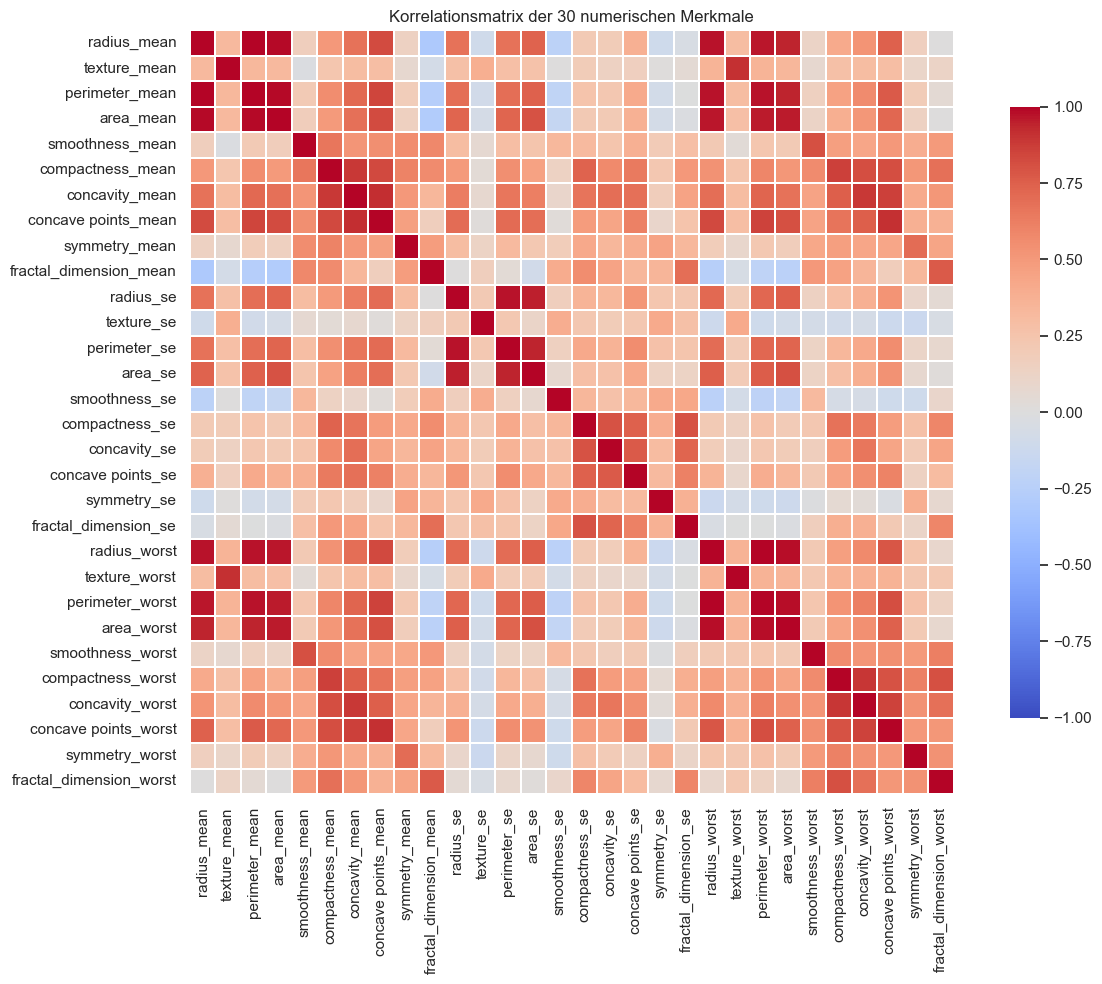

In [6]:
# Korrelationsmatrix der numerischen Merkmale (ohne id und Unnamed: 32)
feature_cols = [c for c in df.columns if c not in ['id', 'diagnosis', 'Unnamed: 32']]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Korrelationsmatrix der 30 numerischen Merkmale')
plt.tight_layout()
plt.show()

Die Heatmap bestätigt die erwartete, sehr starke positive Korrelation zwischen `radius`, `perimeter` und `area` (jeweils in den Varianten `_mean`, `_se` und `_worst`), was geometrisch plausibel ist. Auch `concavity`, `concave points` und `compactness` korrelieren stark miteinander, da sie alle die Unregelmäßigkeit des Zellkernrandes auf leicht unterschiedliche Weise quantifizieren. Eine Reduktion oder gezielte Auswahl korrelierter Merkmale könnte sinnvoll sein, um die Modelle robuster und interpretierbarer zu machen.

Um zu beurteilen, wie gut sich die beiden Diagnoseklassen anhand einzelner Merkmale trennen lassen, vergleichen wir im Folgenden die Verteilungen ausgewählter `_worst`-Merkmale getrennt nach `diagnosis`.

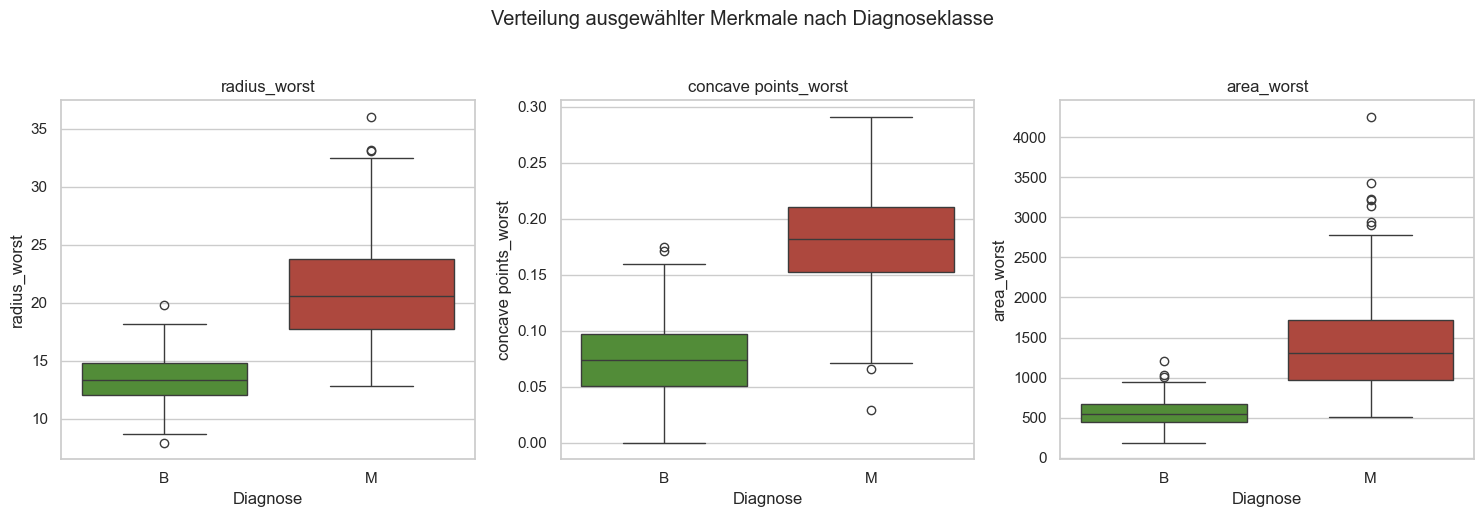

In [7]:
# Verteilung ausgewählter, klinisch aussagekräftiger Merkmale je Diagnoseklasse
selected_features = ['radius_worst', 'concave points_worst', 'area_worst']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feature in zip(axes, selected_features):
    sns.boxplot(data=df, x='diagnosis', y=feature, hue='diagnosis', order=['B', 'M'],
                palette={'B': '#4C9A2A', 'M': '#C0392B'}, legend=False, ax=ax)
    ax.set_xlabel('Diagnose')
    ax.set_title(feature)
fig.suptitle('Verteilung ausgewählter Merkmale nach Diagnoseklasse', y=1.03)
plt.tight_layout()
plt.show()

Die Boxplots zeigen für alle drei Merkmale (`radius_worst`, `concave points_worst`, `area_worst`) eine deutliche Verschiebung der bösartigen Klasse (M) zu höheren Werten, mit nur geringer Überlappung der Interquartilsbereiche. Besonders `concave points_worst` trennt die Klassen sehr klar: Bösartige Befunde haben tendenziell mehr und stärker ausgeprägte konkave Randpunkte. Das ist medizinisch nachvollziehbar, dass maligne Zellkerne unregelmäßiger wachsen und eingebuchtete Konturen bilden, während benigne Kerne eher glatt und rund sind.

Wenn sich die maligne Klasse schon anhand einzelner Merkmale deutlich abhebt, ist ein Modell mit hohem Recall grundsätzlich realistisch. Gleichzeitig sieht man vereinzelt Ausreißer und Überlappungen (z. B. ein paar gutartige Befunde mit ungewöhnlich hohem `area_worst`). Solche Grenzfälle werden für die Modelle vermutlich am schwierigsten und genau hier bleibt die menschliche Zweitprüfung wichtig.

Zum Abschluss der EDA halten wir drei Punkte fest: (1) Der Datensatz ist sauber und fast vollständig, die Data Preparation kann sich also auf das Entfernen irrelevanter Spalten und die Skalierung konzentrieren. (2) Viele Merkmale korrelieren stark miteinander und das berücksichtigen wir bei der Merkmalsauswahl. (3) Die beiden Klassen lassen sich schon anhand einzelner Merkmale gut trennen, was einen hohen Recall für die bösartige Klasse realistisch erscheinen lässt.

---
# 3. Data Preparation

In dieser Phase bringen wir den Rohdatensatz in eine Form, mit der wir modellieren können. Alle Schritte bauen direkt auf den Erkenntnissen aus Phase 2 auf: irrelevante Spalten und Importartefakte, die starken Korrelationen zwischen den geometrischen Merkmalen und die sehr unterschiedlichen Skalen der Features. Wichtig ist uns dabei eine strikte Trennung von Trainings- und Testdaten. Zu keinem Zeitpunkt fließen Informationen aus dem Testset in die Vorverarbeitung ein (kein Data Leakage).

In [8]:
df_raw = pd.read_csv('data.csv')
print(f"Originaldatensatz: {df_raw.shape[0]} Zeilen × {df_raw.shape[1]} Spalten")

Originaldatensatz: 569 Zeilen × 33 Spalten


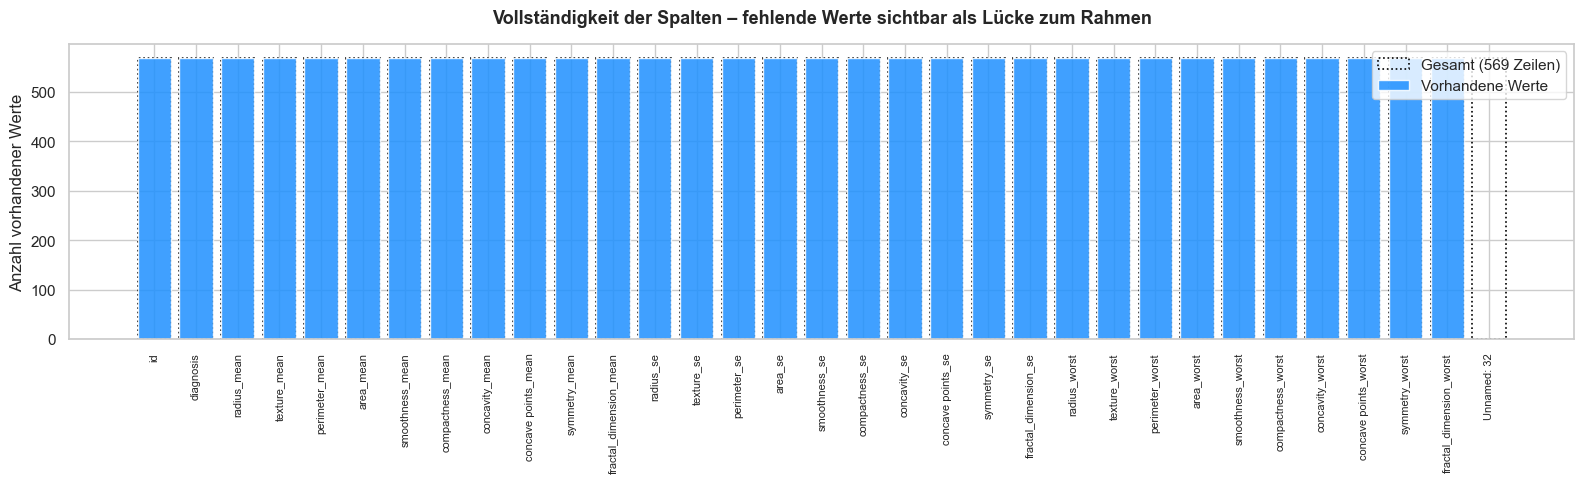

Spalten mit fehlenden Werten:
Unnamed: 32    569


In [9]:
# Vollständigkeit aller Spalten vor der Bereinigung visualisieren
gesamt_zeilen = len(df_raw)
vorhandene_werte = df_raw.count()

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(vorhandene_werte.index, [gesamt_zeilen] * len(vorhandene_werte),
       color='none', edgecolor='black', linewidth=1.2, linestyle=':',
       label=f'Gesamt ({gesamt_zeilen} Zeilen)')
ax.bar(vorhandene_werte.index, vorhandene_werte,
       color='dodgerblue', alpha=0.85, label='Vorhandene Werte')
ax.set_title("Vollständigkeit der Spalten – fehlende Werte sichtbar als Lücke zum Rahmen",
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel("Anzahl vorhandener Werte")
ax.set_xticks(range(len(vorhandene_werte)))
ax.set_xticklabels(vorhandene_werte.index, rotation=90, fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

# Spalten mit fehlenden Werten tabellarisch ausgeben
missing = df_raw.isnull().sum()
print("Spalten mit fehlenden Werten:")
print(missing[missing > 0].to_string() if missing.sum() > 0 else "  → Keine")

## 3.1 Datenselektion & Filterung

Zuerst entfernen wir irrelevante Spalten und Artefakte, kodieren die Zielvariable und treffen dann eine gezielte Merkmalsauswahl auf Basis der Korrelationsanalyse aus Phase 2.

**Identifikatoren und Artefakte entfernen:** Die Spalte `id` fliegt raus, weil eine reine Kennung nichts über die Bösartigkeit aussagt. Im schlimmsten Fall würde ein Modell sogar zufällige Muster in den IDs lernen. `Unnamed: 32` ist das bekannte Import-Artefakt (abschließendes Komma in der CSV) und komplett leer, also ebenfalls raus.

**Zielvariable kodieren:** `diagnosis` lag als Text vor. Da die Algorithmen Zahlen brauchen, kodieren wir: `M` (bösartig) → `1`, `B` (gutartig) → `0`. Die kritische Klasse bewusst als `1`.Das macht die spätere Interpretation von Recall, Precision und Confusion Matrix intuitiver.

**Multikollinearität reduzieren (Feature Selection):** In Phase 2 hat sich gezeigt, dass `radius`, `perimeter` und `area` fast perfekt korrelieren (r > 0,99) und das ist kein Wunder, denn sie hängen geometrisch direkt zusammen (Umfang $2\pi r$, Fläche $\pi r^2$). Alle drei gleichzeitig zu behalten, destabilisiert vor allem lineare Modelle und macht die Koeffizienten schwerer interpretierbar. Wir entfernen deshalb die Familien `perimeter` und `area` (je `_mean`, `_se`, `_worst`, also 6 Spalten) und behalten `radius` als Vertreter der Größendimension. Danach bleiben **24 Features** übrig (statt 30).

**Datenintegrität:** Es gibt keine doppelten Zeilen, und nach der Bereinigung fehlen keine Werte mehr. Imputation ist also nicht nötig.

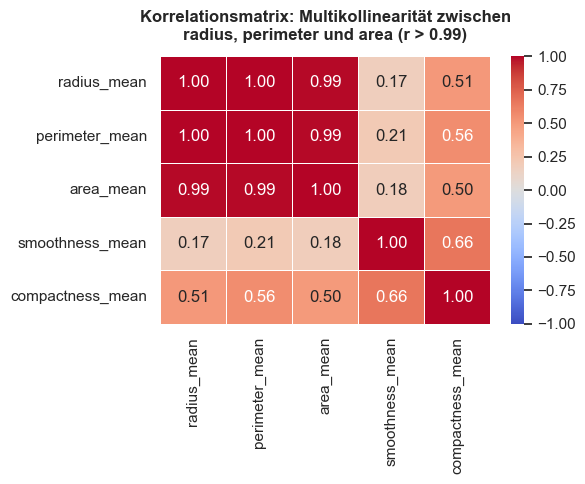

Entfernte Artefakt-Spalten  : ['id', 'Unnamed: 32']
Entfernte redundante Spalten: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'perimeter_worst', 'area_worst']
Duplikate                   : 0
Fehlende Werte              : 0
Verbleibende Features       : 24
Datensatzform               : 569 Zeilen × 25 Spalten



,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,...,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,0.3726,14.1273,19.2896,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,0.4052,...,0.0205,0.0038,16.2692,25.6772,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839
std,0.4839,3.5240,4.3010,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,0.2773,...,0.0083,0.0026,4.8332,6.1463,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181
min,0.0000,6.9810,9.7100,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,0.1115,...,0.0079,0.0009,7.9300,12.0200,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550
25%,0.0000,11.7000,16.1700,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,0.2324,...,0.0152,0.0022,13.0100,21.0800,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715
50%,0.0000,13.3700,18.8400,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,0.3242,...,0.0187,0.0032,14.9700,25.4100,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800
75%,1.0000,15.7800,21.8000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,0.4789,...,0.0235,0.0046,18.7900,29.7200,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921
max,1.0000,28.1100,39.2800,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,2.8730,...,0.0790,0.0298,36.0400,49.5400,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075


In [10]:
# Arbeitskopie
df = df_raw.copy()

# 1. Artefakte und Identifikatoren entfernen
cols_to_drop = ['id', 'Unnamed: 32']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Zielvariable kodieren: M → 1, B → 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 3. Korrelationsheatmap — VOR der Feature Selection, perimeter/area noch vorhanden
mean_features = ['radius_mean', 'perimeter_mean', 'area_mean',
                 'smoothness_mean', 'compactness_mean']

plt.figure(figsize=(6, 5))
sns.heatmap(df[mean_features].corr(),
            annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Korrelationsmatrix: Multikollinearität zwischen\nradius, perimeter und area (r > 0.99)",
          fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# 4. Redundante Features entfernen (perimeter_* und area_* — je 3 Varianten = 6 Spalten)
redundant_cols = [col for col in df.columns if 'perimeter' in col or 'area' in col]
df = df.drop(columns=redundant_cols)

# Überblick nach Bereinigung
print(f"Entfernte Artefakt-Spalten  : {cols_to_drop}")
print(f"Entfernte redundante Spalten: {redundant_cols}")
print(f"Duplikate                   : {df.duplicated().sum()}")
print(f"Fehlende Werte              : {df.isnull().sum().sum()}")
print(f"Verbleibende Features       : {df.shape[1] - 1}")
print(f"Datensatzform               : {df.shape[0]} Zeilen × {df.shape[1]} Spalten\n")
display(df.describe().round(4))

## 3.2 Transformation & Feature-Engineering

### Train-Test-Split

Wir teilen die Daten **vor** jeder weiteren Transformation in Trainings- und Testdaten auf. Diese Reihenfolge ist wichtig: Würden wir den Scaler auf dem gesamten Datensatz fitten, flössen Kennwerte des Testsets (Mittelwert, Standardabweichung) in die Transformation ein, was ein klassisches Data Leakage ist, das die Bewertung zu optimistisch macht.

Aufgeteilt wird im Verhältnis **80 % Training / 20 % Test** mit `stratify=y`, sodass die Klassenverteilung (≈ 63 % B / 37 % M) in beiden Teilen erhalten bleibt. Ein fester `random_state=42` sorgt für Reproduzierbarkeit.

### Feature Scaling (Z-Score-Standardisierung)

Die 24 Features haben sehr unterschiedliche Skalen (z. B. `radius_mean` ≈ 6–28 vs. `smoothness_mean` ≈ 0,05–0,16). Für die logistische Regression ist eine einheitliche Skalierung sinnvoll, sonst können einzelne Features mit großen Zahlenbereichen die Schätzung dominieren.

Wir nutzen den **`StandardScaler`** (Z-Score: $z = (x - \mu)/\sigma$). Gefittet wird er **nur auf den Trainingsdaten** (`fit_transform`), und mit denselben Parametern transformieren wir dann das Testset (`transform`). Der Decision Tree bräuchte die Skalierung streng genommen nicht, aber wir behalten für beide Modelle dieselbe Datengrundlage bei, damit der Vergleich fair bleibt.


### Fehlende Werte & weiteres Feature-Engineering

Nach der Bereinigung in 3.1 fehlen keine Werte mehr, Imputation ist also nicht nötig. Auf synthetisches Oversampling (z. B. SMOTE) verzichten wir bewusst: Die Verteilung von ca. 63 % zu 37 % ist zwar nicht ausgeglichen, aber noch moderat. Stattdessen berücksichtigen wir die Ungleichheit in Phase 4 direkt über `class_weight='balanced'`, damit die Modelle die häufigere gutartige Klasse nicht zu stark bevorzugen.

In [11]:
# Features und Zielvariable trennen
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Stratifizierter Split 80/20 —  VOR der Skalierung
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Trainingsdaten : {X_train.shape[0]} Befunde "
      f"({y_train.sum()} malignant / {(y_train == 0).sum()} benign)")
print(f"Testdaten      : {X_test.shape[0]} Befunde  "
      f"({y_test.sum()} malignant / {(y_test == 0).sum()} benign)")
print(f"\nKlassenanteil Malignant — "
      f"Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}  ✓ (stratifiziert)")

Trainingsdaten : 455 Befunde (170 malignant / 285 benign)
Testdaten      : 114 Befunde  (42 malignant / 72 benign)

Klassenanteil Malignant — Train: 37.4%  |  Test: 36.8%  ✓ (stratifiziert)


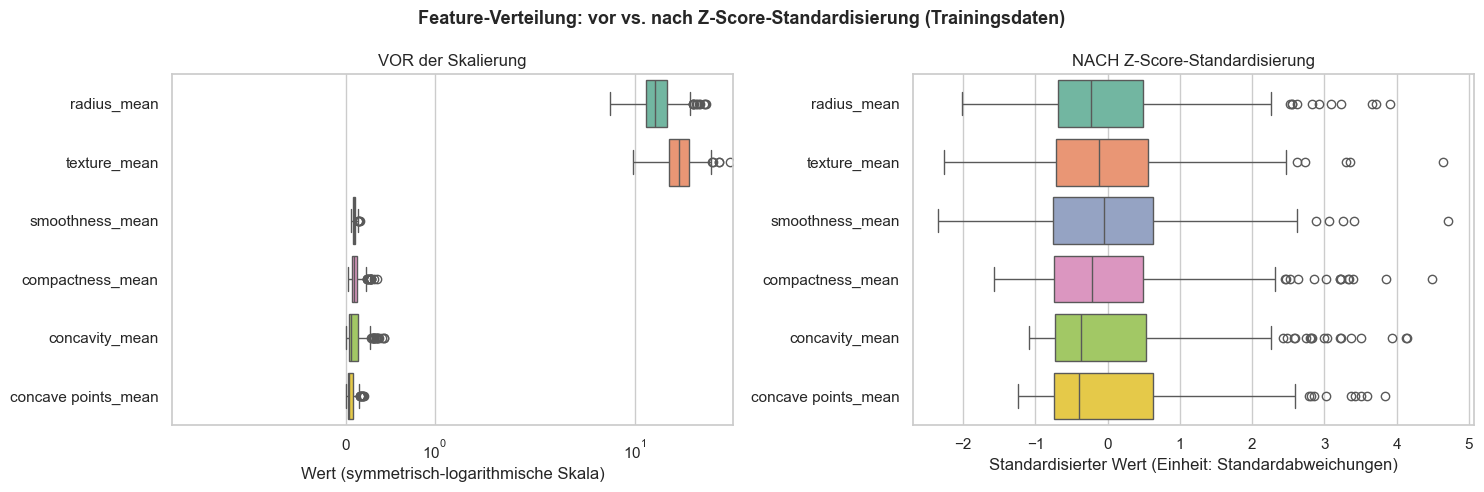

In [12]:
# Fit NUR auf Trainingsdaten — transform auf beiden Splits
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# --- Plot 1: Statischer Vorher/Nachher-Vergleich (seaborn) ---
features_show = X_train.columns[:6].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Feature-Verteilung: vor vs. nach Z-Score-Standardisierung (Trainingsdaten)",
             fontsize=13, fontweight='bold')

sns.boxplot(data=X_train[features_show], orient='h', ax=axes[0], palette='Set2')
axes[0].set_title("VOR der Skalierung")
axes[0].set_xscale('symlog')
axes[0].set_xlabel("Wert (symmetrisch-logarithmische Skala)")

sns.boxplot(data=X_train_scaled[features_show], orient='h', ax=axes[1], palette='Set2')
axes[1].set_title("NACH Z-Score-Standardisierung")
axes[1].set_xlabel("Standardisierter Wert (Einheit: Standardabweichungen)")

plt.tight_layout()
plt.show()

# --- Plot 2: Interaktive Übersicht aller 20 Features nach Skalierung (plotly) ---
df_scaled_melted = X_train_scaled.melt(
    var_name='Feature',
    value_name='Standardisierter Wert'
)

fig_plotly = px.box(
    df_scaled_melted,
    x='Standardisierter Wert',
    y='Feature',
    color='Feature',
    orientation='h',
    title="Interaktive Verteilung aller 24 Features nach Z-Score-Standardisierung (Trainingsdaten)",
    height=700
)
fig_plotly.update_layout(showlegend=False)
fig_plotly.show()

## Zusammenfassung & Übergang zu Phase 4

Die Data-Preparation-Phase hat den Rohdatensatz in eine saubere, modellierungsfähige Form überführt. Die wichtigsten Ergebnisse im Überblick:

| Schritt | Ausgangszustand | Ergebnis |
|---|---|---|
| Artefakte entfernt | 33 Spalten | `id`, `Unnamed: 32` gedroppt |
| Zielvariable kodiert | `M` / `B` (String) | `1` / `0` (numerisch) |
| Feature Selection | 30 Features | 6 entfernt (`perimeter_*`, `area_*`) → **24 Features** |
| Fehlende Werte | `Unnamed: 32` (100 % NaN) | **0 fehlende Werte** nach Bereinigung |
| Train-Test-Split | 569 Befunde | **455 Training** / **114 Test** (80/20, stratifiziert) |
| Skalierung | Heterogene Skalen | Z-Score-Standardisierung (Fit: nur Trainingsdaten) |

Der Datensatz ist nun vollständig bereinigt, dimensionsreduziert und korrekt aufgeteilt. Alle vier Outputobjekte (`X_train_scaled`, `X_test_scaled`, `y_train` und `y_test`) stehen für Phase 4 bereit.

In **Phase 4 (Modeling)** werden auf dieser Grundlage mehrere Klassifikationsmodelle trainiert und verglichen. Der Fokus liegt dabei auf der Optimierung des **Recalls für die kritische Klasse Malignant (1)**, wie in den Erfolgskriterien aus Phase 1 definiert (Recall ≥ 0,95, Precision ≥ 0,90). Um der moderaten Klassenunbalance (63:37) zu begegnen, wird der Parameter `class_weight='balanced'` eingesetzt, sodass das Modell Fehlklassifikationen maligner Befunde stärker bestraft als solche benigner Fälle.

### Warum kein separates Validierungsset?

Wir haben uns bewusst gegen einen 3-Wege-Split (Training / Validation / Test) entschieden. Der Hauptgrund ist die geringe Größe des Datensatzes (nur 569 Befunde). Ein drittes Set hätte die Trainingsdaten zu stark verkleinert. Gerade bei den selteneren bösartigen Fällen (nur 37 %) hätte den Modellen dann die Datenmenge für robustes Lernen gefehlt. Die Modellstabilität prüfen wir stattdessen über die stratifizierte Kreuzvalidierung in Phase 4.

---
# 4. Modeling

Für die Analyse haben wir zwei Modelle ausgewählt: eine logistische Regression und einen Decision Tree Classifier. Sie arbeiten unterschiedlich und eignen sich deshalb gut für einen Vergleich: Die logistische Regression dient als eher einfaches lineares Modell, während der Decision Tree regelbasiert vorgeht. So können wir prüfen, ob beide Ansätze die vorbereiteten Zellkernmerkmale ähnlich gut zur Klassifikation nutzen. Da es um einen medizinischen Datensatz geht, ist außerdem wichtig, dass die Grundidee der Modelle nachvollziehbar bleibt.

Beide Modelle wurden mit `scikit-learn` umgesetzt und auf denselben Trainingsdaten trainiert. Das Testset bleibt getrennt und wird erst in der Evaluation verwendet. Dadurch können die Ergebnisse der beiden Modelle fair verglichen werden.

## 4.1 Modell 1: Logistische Regression

Als erstes Modell haben wir die logistische Regression gewählt. Für unseren Datensatz passt sie gut, weil die Zielvariable nur zwei Ausprägungen hat: gutartig (`0`) und bösartig (`1`). Das Modell gibt für jeden Fall eine Wahrscheinlichkeit aus, ob er eher zur Klasse `1` gehört. Daraus entsteht dann die Vorhersage.

Für uns ist die logistische Regression vor allem ein guter Startpunkt. Sie ist kein besonders komplexes Modell, aber genau deshalb gut als Vergleichsbasis geeignet. Wenn die Ergebnisse hier schon gut sind, sieht man, dass die vorbereiteten Zellkernmerkmale grundsätzlich genug Information für die Unterscheidung der beiden Diagnosegruppen enthalten.

Außerdem bleibt die Modellidee relativ leicht verständlich. Das ist bei einem medizinischen Datensatz wichtig, weil man nicht nur auf die Kennzahlen schauen sollte, sondern auch verstehen muss, wie eine Klassifikation zustande kommt. Die logistische Regression dient daher als Baseline, mit der wir den Decision Tree später vergleichen können.

Die Implementierung erfolgt mit `LogisticRegression` aus `scikit-learn`. Das Modell wird mit `X_train_scaled` und `y_train` trainiert. Die Skalierung aus Phase 3 ist wichtig, weil die logistische Regression durch sehr unterschiedliche Wertebereiche der Features beeinflusst werden kann. Zusätzlich setzen wir `class_weight='balanced'`, damit die Klasse `1` beim Training nicht zu wenig berücksichtigt wird. Mit `max_iter=1000` bekommt das Modell genügend Iterationen für die Optimierung.

In [13]:
# Das Modell wird mit class_weight='balanced' erstellt,
# damit die seltenere Klasse (bösartig = 1) beim Training berücksichtigt wird
log_reg_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

# Training des Modells mit den in Phase 3 vorbereiteten Trainingsdaten
# X_train_scaled enthält die skalierten Features
# y_train enthält die zugehörigen Diagnose-Labels
log_reg_model.fit(X_train_scaled, y_train)

# Kreuzvalidierung für die Logistische Regression
cv_scores = cross_val_score(log_reg_model, X_train_scaled, y_train, cv=5, scoring='recall')

print(f"Kreuzvalidierung (Recall pro Fold): {cv_scores.round(4)}")
print(f"Durchschnittlicher Recall (CV): {cv_scores.mean():.4f}")
print(f"Standardabweichung (CV): {cv_scores.std():.4f}")

# Kurze Bestätigung, dass das Modell trainiert wurde
print("Logistische Regression wurde erfolgreich trainiert.")

Kreuzvalidierung (Recall pro Fold): [0.9412 1.     0.9118 1.     0.9706]
Durchschnittlicher Recall (CV): 0.9647
Standardabweichung (CV): 0.0343
Logistische Regression wurde erfolgreich trainiert.


Die Kreuzvalidierung zeigt mit einem durchschnittlichen Recall von 0,9647, dass wir das Primärziel (Recall ≥ 0,95) zuverlässig übertreffen. Das Modell erkennt bösartige Tumore also über verschiedene Datenaufteilungen hinweg gut.

Die Standardabweichung liegt mit 0,0343 allerdings knapp über unserem Stabilitätsziel (≤ 0,03). Der Blick auf die einzelnen Folds erklärt das: In zwei von fünf Durchläufen arbeitet das Modell fehlerfrei (Recall 1,0), fällt in einem Durchlauf aber auf 0,9118 ab. Das liegt vor allem an der geringen Datenmenge. Ein einzelner Test-Fold enthält nur rund 34 bösartige Fälle, sodass schon zwei bis drei übersehene Tumore den Wert prozentual stark drücken. Insgesamt ist die Erkennungsrate aber sehr gut und praxistauglich.

## 4.2 Modell 2: Decision Tree Classifier

Als zweites Modell verwenden wir einen Decision Tree Classifier. Er funktioniert anders als die logistische Regression: Statt einer linearen Trennung teilt er die Daten Schritt für Schritt nach einzelnen Feature-Werten auf. Vereinfacht gesagt prüft der Baum z. B., ob ein bestimmtes Zellkernmerkmal über oder unter einem Schwellenwert liegt.

Für unser Projekt ist dieses Modell interessant, weil in Phase 2 schon sichtbar wurde, dass sich einige Merkmale zwischen gutartigen und bösartigen Befunden unterscheiden. Ein Entscheidungsbaum kann solche Unterschiede direkt als Regeln abbilden. Dadurch ist er anschaulich und eignet sich gut als Vergleich zur logistischen Regression.

Umgesetzt wird das Modell mit `DecisionTreeClassifier` aus `scikit-learn`. Trainiert wird es mit denselben Daten (`X_train_scaled`, `y_train`) wie die logistische Regression, damit beide auf derselben Grundlage vergleichbar sind. Die Skalierung wäre für einen Baum zwar nicht nötig, wir behalten sie aber für einen einheitlichen Workflow bei. Mit `class_weight='balanced'` berücksichtigen wir wieder die Klassenverteilung, und mit `max_depth=4` begrenzen wir die Tiefe, damit der Baum nicht zu stark auf die Trainingsdaten zugeschnitten ist (Overfitting). `random_state=42` macht die Ergebnisse reproduzierbar.

In [14]:
# Der Decision Tree arbeitet regelbasiert.
# Mit max_depth=4 begrenzen wir die Tiefe des Baums,
# damit das Modell übersichtlich bleibt und nicht zu stark overfittet
decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=4,
    random_state=42
)

# Training des Modells mit denselben vorbereiteten Trainingsdaten
# wie bei der logistischen Regression
decision_tree_model.fit(X_train_scaled, y_train)

# Kurze Bestätigung, dass das Modell trainiert wurde
print("Decision Tree Classifier wurde erfolgreich trainiert.")

Decision Tree Classifier wurde erfolgreich trainiert.


In [15]:
# Kreuzvalidierung für den Decision Tree
cv_scores_tree = cross_val_score(decision_tree_model, X_train_scaled, y_train, cv=5, scoring='recall')

print(f"Kreuzvalidierung Tree (Recall pro Fold): {cv_scores_tree.round(4)}")
print(f"Durchschnittlicher Recall Tree (CV): {cv_scores_tree.mean():.4f}")
print(f"Standardabweichung Tree (CV): {cv_scores_tree.std():.4f}")

Kreuzvalidierung Tree (Recall pro Fold): [0.9118 0.9706 0.8235 0.9706 0.8824]
Durchschnittlicher Recall Tree (CV): 0.9118
Standardabweichung Tree (CV): 0.0558


Die Kreuzvalidierung des Decision Trees liefert einen durchschnittlichen Recall von 0,9118. Damit wird das definierte Primärziel (Recall ≥ 0,95) für die Erkennung bösartiger Tumore klar verfehlt. Ebenso wird das Stabilitätskriterium nicht erfüllt: Die Standardabweichung liegt mit 0,0558 deutlich über dem erlaubten Maximalwert von ≤ 0,03.

Ein Blick auf die einzelnen Folds zeigt den Grund für diese hohe Varianz. Die Leistung des Baums schwankt extrem je nach Datenaufteilung: In zwei Durchgängen werden sehr gute 97,06 % (0,9706) der Tumore erkannt, während der Wert in einem anderen Fold auf besorgniserregende 82,35 % (0,8235) abstürzt. Das bedeutet, dass in diesem schlechtesten Durchlauf fast 18 % der Krebspatienten übersehen wurden.

Diese Ergebnisse verdeutlichen eine Lernerfahrung: Der Decision Tree reagiert extrem sensibel auf die exakte Zusammensetzung der Trainingsdaten. Trotz der vorgenommenen Tiefenbegrenzung (max_depth=4) erweist sich das Modell auf diesem kleinen Datensatz als zu instabil und unzuverlässig, um unsere strengen Sicherheitsanforderungen des Projekts zu erfüllen. Im direkten Vergleich ist die logistische Regression hier deutlich überlegen.

Zur Absicherung dieser Wahl haben wir zusätzlich verschiedene Werte für max_depth verglichen. Ein Vergleich von max_depth 3 bis 6 zeigte, dass tiefere Bäume den Recall der bösartigen Klasse nicht verbessern (0,88 bleibt konstant), in der Kreuzvalidierung aber leicht instabiler werden. max_depth=4 ist also die sinnvollste Wahl.

---
# 5. Evaluation

## 5.1 Evaluationsmetriken

Bei der Evaluation verwenden wir Accuracy zwar als ergänzende Kennzahl, sie ist für unser Projekt jedoch nicht das zentrale Bewertungskriterium. Ein Modell kann insgesamt viele Fälle richtig klassifizieren und trotzdem gerade bei der medizinisch wichtigeren Klasse Fehler machen. In unserem Fall wäre insbesondere problematisch, wenn ein bösartiger Befund als gutartig vorhergesagt wird.

Deshalb verwenden wir neben Accuracy auch Precision, Recall, F1-Score und die Confusion Matrix. Diese Metriken werden in Arbeiten zu medizinischen KI-Anwendungen ebenfalls häufig für Klassifikationsmodelle diskutiert (Hicks et al., 2022; Rainio et al., 2024; Kocak et al., 2025). Für unser Projekt ist besonders der Recall der Klasse `1` wichtig, weil diese Klasse die bösartigen Befunde beschreibt. Er zeigt, wie viele der tatsächlich bösartigen Fälle erkannt wurden. Precision ergänzt das, weil sie zeigt, wie zuverlässig eine Vorhersage als bösartig ist. Der F1-Score hilft, beide Werte zusammen zu betrachten. Die Confusion Matrix nutzen wir zusätzlich, um die Fehler als konkrete Fallzahlen zu sehen.

## 5.2 Threshold-Anpassung (Standard 0,5 → 0,35)

Bei der ersten Auswertung der logistischen Regression haben wir den Standard-Schwellenwert von 0,5 genutzt (das Standardverhalten von `.predict()`). Damit lag der Recall bei 0,93. Unser Ziel (Recall ≥ 0,95) haben wir also knapp verfehlt.

Hier greift direkt das Leitprinzip aus 1.5: Weil ein übersehener Krebsfall ungleich schwerer wiegt als ein Fehlalarm, ist ein etwas zu vorsichtiges Modell für uns besser als ein zu nachlässiges. Also senken wir den Schwellenwert auf **0,35**. Das Modell stuft einen Befund schon ab einer Wahrscheinlichkeit von 35 % als bösartig ein.

Der Schwellenwert wurde in diesem Projekt explorativ angepasst, um den Zielkonflikt zwischen Recall und Precision zu untersuchen. In einer produktiven Anwendung oder einer wissenschaftlichen Studie sollte der optimale Schwellenwert ausschließlich anhand der Trainingsdaten beziehungsweise eines separaten Validierungsdatensatzes oder mittels Cross-Validation bestimmt werden. Dadurch bleibt das Testset vollständig unabhängig und dient ausschließlich der abschließenden Bewertung des Modells.

Der Effekt: Der Recall steigt auf etwa 98 %, das Modell übersieht also deutlich weniger bösartige Tumore. Den Preis dafür sind ein paar zusätzliche Fehlalarme, die wir bewusst in Kauf nehmen.

In [16]:
# Vorhersagen der beiden Modelle auf dem Testdatensatz

# Vorhersage des Decision Trees bleibt normal
y_pred_tree = decision_tree_model.predict(X_test_scaled)

# Anpassung des Thresholds für die Logistische Regression
# predict_proba liefert die Wahrscheinlichkeit für Klasse 1 (Bösartig)
y_proba_log_reg = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Neuer Schwellenwert (z.B. 0.35 statt Standard 0.5)
threshold = 0.35
y_pred_log_reg = (y_proba_log_reg >= threshold).astype(int)



# Classification Report für beide Modelle
# Der Report zeigt Precision, Recall, F1-Score und Support pro Klasse.

print("Logistische Regression")
print(classification_report(
    y_test,
    y_pred_log_reg,
    target_names=["Gutartig (0)", "Bösartig (1)"]
))

print("Decision Tree Classifier")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["Gutartig (0)", "Bösartig (1)"]
))


# Die Reports werden zusätzlich als Dictionary gespeichert,
# damit einzelne Werte für eine Vergleichstabelle genutzt werden können.

report_log_reg = classification_report(y_test, y_pred_log_reg, output_dict=True)
report_tree = classification_report(y_test, y_pred_tree, output_dict=True)


# Kompakte Vergleichstabelle
# Fokus auf Klasse 1 (bösartige, für uns besonders kritisch).

evaluation_results = pd.DataFrame({
    "Modell": ["Logistische Regression", "Decision Tree Classifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision Klasse 1": [
        report_log_reg["1"]["precision"],
        report_tree["1"]["precision"]
    ],
    "Recall Klasse 1": [
        report_log_reg["1"]["recall"],
        report_tree["1"]["recall"]
    ],
    "F1-Score Klasse 1": [
        report_log_reg["1"]["f1-score"],
        report_tree["1"]["f1-score"]
    ]
})

# Werte für eine bessere Lesbarkeit auf drei Nachkommastellen runden
evaluation_results.round(3)

Logistische Regression
              precision    recall  f1-score   support

Gutartig (0)       0.99      0.99      0.99        72
Bösartig (1)       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Decision Tree Classifier
              precision    recall  f1-score   support

Gutartig (0)       0.93      0.99      0.96        72
Bösartig (1)       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



,Modell,Accuracy,Precision Klasse 1,Recall Klasse 1,F1-Score Klasse 1
0,Logistische Regression,0.982,0.976,0.976,0.976
1,Decision Tree Classifier,0.947,0.974,0.881,0.925


## Heuristik Baseline
Um die tatsächliche Leistungsfähigkeit unseres Modells objektiv bewerten zu können, benötigen wir einen Vergleichswert, also eine Baseline. Dafür haben wir eine simple Heuristik erstellt. Basierend auf unserer vorherigen Feature-Importance-Analyse nutzen wir ausschließlich das wichtigste Merkmal (radius_worst) und definieren die Regel: "Wenn die Zelle größer als der Durchschnitt ist, wird sie als bösartig (1) klassifiziert, ansonsten als gutartig (0)".

In [17]:
# Erstellung einer einfachen Heuristik (Baseline):
# 1 (bösartig/maligne), wenn der Radius größer als der Durchschnitt ist (skalierter Wert > 0)
y_pred_heuristic = (X_test_scaled['radius_worst'] > 0).astype(int)

# Evaluierung der Ergebnisse
print("--- Ergebnisse der einfachen Heuristik (radius_worst > Durchschnitt) ---")
print(f"Recall:    {recall_score(y_test, y_pred_heuristic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_heuristic):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_heuristic):.4f}")

--- Ergebnisse der einfachen Heuristik (radius_worst > Durchschnitt) ---
Recall:    0.8333
Precision: 0.9211
Accuracy:  0.9123



Die Baseline-Heuristik erzielt zwar eine hohe Accuracy, verpasst aber mit einem Recall von nur 83,3% fast jeden zehnten bösartigen Tumor. Dieser Vergleich war für uns essenziell, da er unmissverständlich beweist, dass eine einfache Daumenregel nicht ausreicht und erst der Einsatz unseres komplexen Machine-Learning-Modells die nötige Sicherheit für den medizinischen Alltag garantiert.

## 5.3 Ergebnisse

Zusätzlich zu den Kennzahlen betrachten wir die Confusion Matrices. Sie zeigen direkt, welche Fälle richtig oder falsch klassifiziert wurden. Die Zeilen stehen für die tatsächlichen Klassen, die Spalten für die vorhergesagten Klassen.

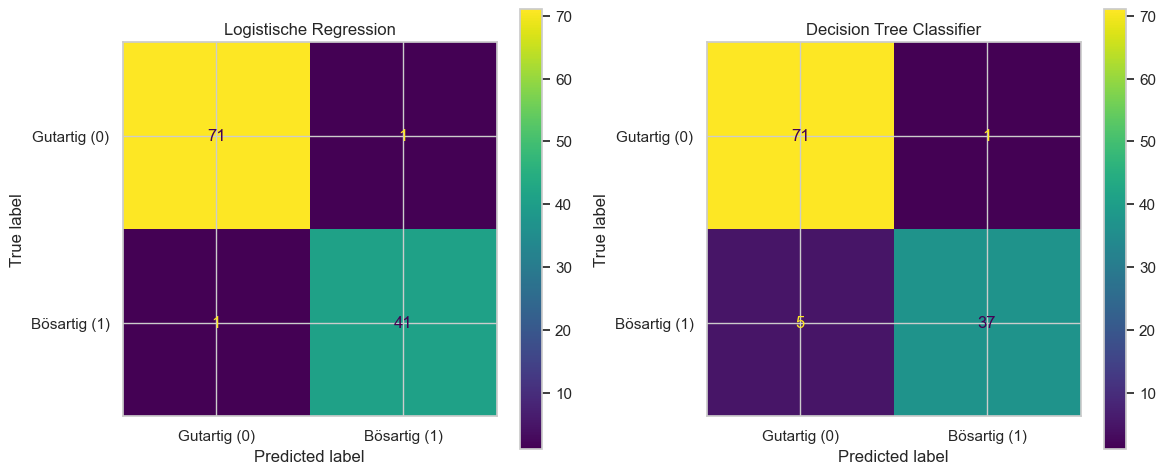

In [18]:
# Confusion Matrices für beide Modelle
# Zeilen = tatsächliche Klassen, Spalten = vorhergesagte Klassen

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix für die logistische Regression
ConfusionMatrixDisplay(
    confusion_matrix=cm_log_reg,
    display_labels=["Gutartig (0)", "Bösartig (1)"]
).plot(ax=axes[0], values_format="d")
axes[0].set_title("Logistische Regression")

# Confusion Matrix für den Decision Tree
ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Gutartig (0)", "Bösartig (1)"]
).plot(ax=axes[1], values_format="d")
axes[1].set_title("Decision Tree Classifier")

plt.tight_layout()
plt.show()

### Confusion Matrix – Logistische Regression

In der Confusion Matrix wird die Wirkung der Threshold-Anpassung konkret sichtbar: Beim Standard-Threshold 0,5 lagen im Feld der False Negatives (unten links) noch 3 übersehene Krebsfälle, bei 0,35 nur noch **1**. Genau dieses Feld wollten wir verkleinern, weil es im medizinischen Kontext am teuersten ist. Dass die False Positives im Gegenzug leicht steigen, ist die in 5.2 bewusst akzeptierte Kehrseite.

Beide Modelle liefern auf dem Testset gute Ergebnisse. Die logistische Regression (mit angepasstem Threshold 0,35) erreicht eine Accuracy von ca. 0,98, der Decision Tree ca. 0,95.

Wichtiger als die Accuracy ist für uns aber der Recall der Klasse `1` (bösartig). Hier ist der Unterschied deutlich: Die logistische Regression erkennt ca. 97,6 % der tatsächlich bösartigen Fälle und übersieht nur **1** Fall. Der Decision Tree (Standard-Threshold) erkennt ca. 88,1 % und übersieht **5** Fälle.

Die Precision der Klasse `1` liegt bei beiden Modellen bei etwa 0,97. Wenn ein Fall als bösartig vorhergesagt wird, stimmt das also meistens. Da die logistische Regression bei ähnlicher Precision mehr bösartige Fälle erkennt, ist sie für unseren Anwendungsfall die bessere Wahl.

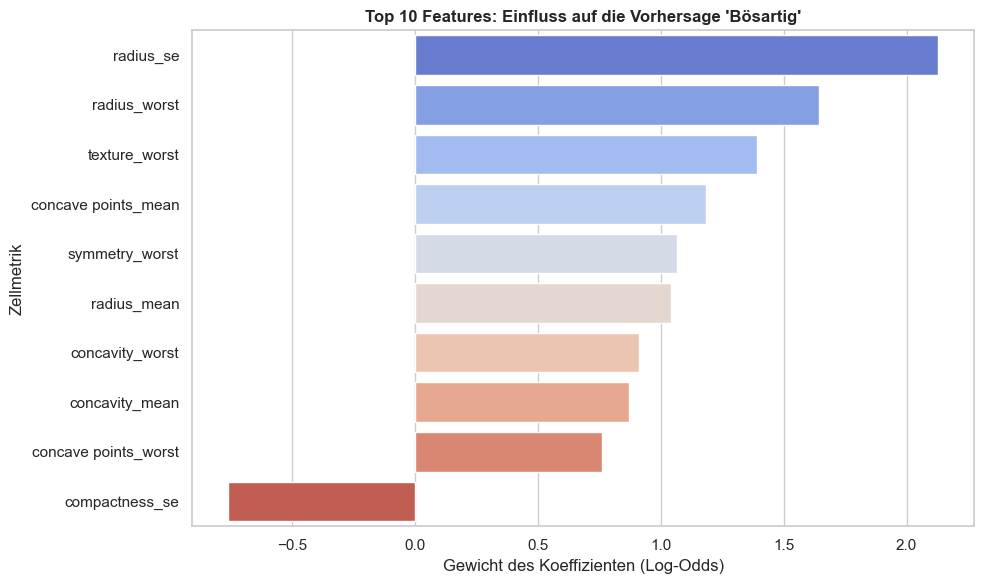

In [19]:
# --- Feature Importance (White-box Modell) ---
# Koeffizienten aus dem logistischen Modell extrahieren
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Nach absoluter Wichtigkeit sortieren
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Coefficient',
    y='Feature',
    palette="coolwarm",
    hue='Feature',
    legend=False
)
plt.title("Top 10 Features: Einfluss auf die Vorhersage 'Bösartig'", fontweight='bold')
plt.xlabel("Gewicht des Koeffizienten (Log-Odds)")
plt.ylabel("Zellmetrik")
plt.tight_layout()
plt.show()

### Interpretation der Koeffizienten

Die logistische Regression ist ein "White-Box"-Modell: Wir können direkt anschauen, welche Merkmale die Vorhersage in welche Richtung schieben.

**Warnsignale (positive Koeffizienten, nach rechts):** Die Balken nach rechts erhöhen die Wahrscheinlichkeit für eine bösartige Diagnose am stärksten. Ganz oben stehen Merkmale rund um die Zellgröße und deren Schwankung – `radius_se` (Standardfehler des Radius) und `radius_worst` (die größten gemessenen Radien). Das passt medizinisch gut: Wachsen Zellen ungewöhnlich stark oder unregelmäßig, ist das ein Warnsignal. Auch Unregelmäßigkeiten am Rand wie `concave points` und `texture_worst` deuten auf Bösartigkeit hin.

**Gegenrichtung (negativer Koeffizient, nach links):** `compactness_se` (Standardfehler der Kompaktheit) wirkt in diesem Modell leicht in die entgegengesetzte Richtung – ein höherer Wert senkt hier die vorhergesagte Wahrscheinlichkeit für "bösartig" minimal ab.

# 6. Deployment & Ausblick

## 6.1 Deployment-Möglichkeiten

In der Praxis würden wir das Modell als Vorfilter einsetzen, nicht als Diagnoseautomat. Die gemessenen Zellkernmerkmale würden eingegeben, das Modell markiert dann verdächtige Fälle, sodass diese früher oder genauer geprüft werden. Die eigentliche Diagnose bleibt bei den Ärzt:innen bzw. Patholog:innen und das Modell übernimmt nur die Vorsortierung.
Das ist bewusst so, denn unser Modell kennt nur die numerischen Zellkernmerkmale aus diesem Datensatz. Alter, Vorgeschichte, Bildmaterial oder weitere Befunde fließen nicht ein. Als alleinige Entscheidungsgrundlage reicht das nicht, aber als schnelle Orientierung im Workflow dagegen schon.

## 6.2 Erweiterungen & Verbesserungen

Vor einer realen Anwendung müsste das Modell breiter getestet werden. Der Datensatz ist klein und sehr sauber; echte klinische Daten variieren stärker. Gute Werte im Testset zeigen daher nur, dass der Ansatz hier funktioniert, aber nicht zwingend auch in anderen Kliniken. Der wichtigste nächste Schritt wäre eine Validierung auf größeren, externen Datensätzen. Gerade bei KI in der Krebsbildgebung gelten diverse Daten und Bias-Awareness als zentrale Punkte (Chouvarda et al., 2025).
Auf solchen größeren, variableren Datensätzen könnte sich auch die Baumtiefe anders verhalten als bei uns. Dort wäre es sinnvoll, verschiedene max_depth-Werte erneut zu testen und die Ergebnisse per Cross-Validation abzusichern. Zusätzlich ließe sich der Entscheidungsschwellenwert weiter optimieren, um noch weniger bösartige Fälle zu übersehen.

---
# 7. Fazit

Das Projekt zeigt, dass der Breast Cancer Wisconsin Datensatz gut geeignet ist, um eine erste Klassifikation von gutartigen und bösartigen Befunden umzusetzen. Wir sind dabei schrittweise entlang der CRISP-DM-Phasen vorgegangen: Zuerst wurde das Problem fachlich eingeordnet, danach wurden die Daten untersucht, bereinigt und für die Modellierung vorbereitet. Besonders wichtig waren dabei die Kodierung der Zielvariable, das Entfernen redundanter Merkmale und die Skalierung der Features.

Die beiden Modelle konnten die Befunde insgesamt gut unterscheiden. Im Vergleich schnitt die logistische Regression etwas besser ab als der Decision Tree Classifier, vor allem beim Recall der Klasse `1`. Für dieses Projekt ist das ein wichtiger Punkt, weil Klasse `1` für bösartige Befunde steht. Ein Modell sollte solche Fälle möglichst nicht übersehen, da False Negatives im medizinischen Kontext besonders kritisch wären.


Gleichzeitig sollte man die Ergebnisse nicht zu stark verallgemeinern. Der Datensatz ist relativ klein, sehr sauber und enthält nur numerische Zellkernmerkmale. Andere klinische Informationen, zum Beispiel Alter, Bilddaten oder ärztliche Einschätzungen, wurden nicht berücksichtigt. Deshalb ist das Modell eher als erster Prototyp zu verstehen und nicht als fertiges Diagnosesystem. Für eine reale Anwendung wären größere externe Datensätze, weitere Validierung und die Einbindung medizinischer Expertise notwendig.

---
# Referenzen

---

UCI Machine Learning. (n.d.). *Breast Cancer Wisconsin (Diagnostic) Data Set.* Kaggle. Abgerufen am 25. Juni 2026, von https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Hossin, M. M., Shamrat, F. M. J. M., Bhuiyan, M. R., Hira, R. A., Khan, T., & Molla, S. (2023). Breast cancer detection: an effective comparison of different machine learning algorithms on the Wisconsin dataset. Bulletin of Electrical Engineering and Informatics, 12(4), 2446-2456. https://doi.org/10.11591/eei.v12i4.4448

Hicks, S. A., Strümke, I., Thambawita, V., Hammou, M., Riegler, M. A., Halvorsen, P., & Parasa, S. (2022). On evaluation metrics for medical applications of artificial intelligence. *Scientific Reports, 12*, Article 5979. https://doi.org/10.1038/s41598-022-09954-8

Rainio, O., Teuho, J., & Klén, R. (2024). Evaluation metrics and statistical tests for machine learning. *Scientific Reports, 14*, Article 6086. https://doi.org/10.1038/s41598-024-56706-x

Kocak, B., Klontzas, M. E., Stanzione, A., Meddeb, A., Demircioglu, A., Bluethgen, C., Bressem, K. K., Ugga, L., Mercaldo, N., Díaz, O., & Cuocolo, R. (2025). Evaluation metrics in medical imaging AI: Fundamentals, pitfalls, misapplications, and recommendations. *European Journal of Radiology Artificial Intelligence, 3*, Article 100030. https://doi.org/10.1016/j.ejrai.2025.100030

Chouvarda, I., Colantonio, S., Verde, A. S. C., Jimenez-Pastor, A., Cerdá-Alberich, L., Metz, Y., Zacharias, L., Nabhani-Gebara, S., Bobowicz, M., Tsakou, G., Lekadir, K., Tsiknakis, M., Martí-Bonmatí, L., & Papanikolaou, N. (2025). Differences in technical and clinical perspectives on AI validation in cancer imaging: Mind the gap! *European Radiology Experimental, 9*, Article 7. https://doi.org/10.1186/s41747-024-00543-0

Plotly Technologies Inc. (2015). *Collaborative data science.* Plotly. https://plotly.com

Scikit-learn developers. (2011). scikit-learn: Machine Learning in Python. scikit-learn. https://scikit-learn.org
